# BASTION: Simulated Data Example

This notebook demonstrates BASTION on a **controlled simulation study**, where the true data-generating process is known.  It reproduces the core results from Section 5 of:

> Cho, J. B. & Matteson, D. S. (2026). *BASTION: A Bayesian Framework for Trend and Seasonality Decomposition.* arXiv:2601.18052.

## What is BASTION?

BASTION (Bayesian Adaptive Seasonality and Trend DecompositION) decomposes a univariate time series into:

- **Trend** — locally smooth, piecewise-linear, estimated with a global-local horseshoe prior on second differences.
- **Seasonal components** — one per specified period *k*, each penalised by second-differencing and seasonal differencing.
- **Outliers** (optional) — sparse additive spikes modelled with a horseshoe+ prior.
- **Remainder** — i.i.d. Gaussian noise, optionally with stochastic volatility.

Posterior inference uses a **Gibbs sampler** with O(N) sparse precision updates (Rue 2001).

## This example

We generate a length-500 series with:
- a piecewise-linear **trend** with four segments and random slopes,
- **two seasonal components** (periods 7 and 30) defined as Fourier pairs,
- **three injected outliers**, and
- i.i.d. Gaussian noise.

We fit BASTION and:
1. Plot the estimated signal (trend + seasonality).
2. Compare the recovered trend to the truth.
3. Inspect individual seasonal components.
4. Report MSE and coverage against paper benchmarks (Tables 2 & 3).

In [1]:
import os, sys, warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

NOTEBOOK_DIR = os.path.abspath(os.getcwd())
PROJECT_DIR  = os.path.abspath(os.path.join(NOTEBOOK_DIR, '..'))
OUTPUT_DIR   = os.path.join(PROJECT_DIR, 'outputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)

sys.path.insert(0, PROJECT_DIR)
from pybastion import fit_BASTION

# ── QUICK_MODE ──────────────────────────────────────────────────────
# True  → short MCMC chain, runs in ~1-3 min (suitable for a quick demo).
# False → full MCMC chain, runs in ~30-60 min (publication-quality results).
QUICK_MODE = True

if QUICK_MODE:
    nsave, nburn, nskip, nchains = 200, 300, 1, 1
else:
    nsave, nburn, nskip, nchains = 2000, 5000, 4, 2

nstot = nburn + (nskip + 1) * nsave
print(f'pybastion loaded from: {PROJECT_DIR}')
print(f'QUICK_MODE={QUICK_MODE}: {nstot} total MCMC steps per chain ')
print(f'  nsave={nsave}, nburn={nburn}, nskip={nskip}, nchains={nchains}')

pybastion loaded from: /media/daniel/Extreme SSD/Projects/pyBASTION
QUICK_MODE=True: 700 total MCMC steps per chain 
  nsave=200, nburn=300, nskip=1, nchains=1


## 1. Generate the Simulated Series

The data-generating process (DGP 1 in Table 1 of the paper) uses:
- Piecewise-linear trend with random slopes drawn from U(-20, 20) × 0.04.
- Two Fourier-pair seasonal components: S7 and S30.
- Additive Gaussian noise with σ = 1.
- Three point outliers with magnitude ±U(15, 25).

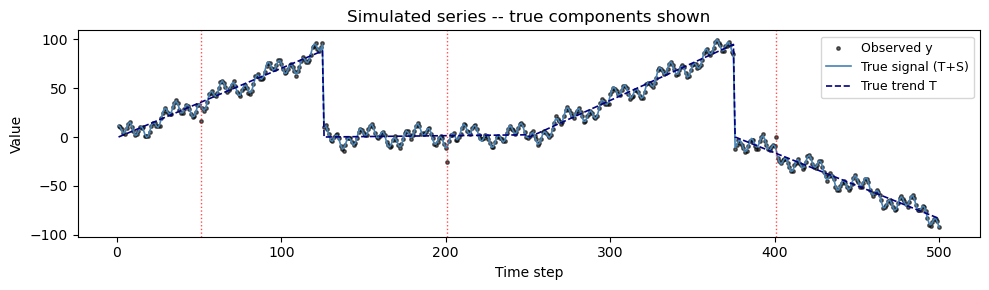

N=500, outlier positions: [50, 200, 400]


In [2]:
def generate_T(n=500, seed=4):
    """Piecewise-linear trend with 4 segments and random slopes."""
    rng = np.random.default_rng(seed)
    slopes = rng.uniform(-20, 20, 4) * 0.04
    bp = [0, 125, 250, 375, 500]
    T = np.zeros(n)
    for i in range(4):
        seg = np.arange(bp[i], bp[i + 1])
        T[seg] = T[bp[i]] + slopes[i] * np.arange(len(seg))
    return T

def gen_sim(n=500, seed=4):
    rng = np.random.default_rng(seed)
    t   = np.arange(1, n + 1)
    T   = generate_T(n, seed=seed)
    S7  = 4 * np.sin(2 * np.pi * t / 7)  + 4 * np.cos(2 * np.pi * t / 7)
    S30 = 5 * np.sin(2 * np.pi * t / 30) + 5 * np.cos(2 * np.pi * t / 30)
    eps = rng.normal(0, 1, n)
    y   = T + S7 + S30 + eps
    out_idx = [50, 200, 400]
    for i in out_idx:
        y[i] += rng.choice([-1, 1]) * rng.uniform(15, 25)
    return {'y': y, 'T': T, 'S7': S7, 'S30': S30, 'outliers': out_idx}

sim = gen_sim(n=500, seed=4)
t   = np.arange(1, 501)

fig, ax = plt.subplots(figsize=(10, 3))
ax.scatter(t, sim['y'], s=6, color='black', alpha=0.6, label='Observed y')
ax.plot(t, sim['T'] + sim['S7'] + sim['S30'],
        linewidth=1.2, color='steelblue', label='True signal (T+S)')
ax.plot(t, sim['T'], linewidth=1.2, color='navy', linestyle='--', label='True trend T')
for i in sim['outliers']:
    ax.axvline(i + 1, color='red', linestyle=':', linewidth=1.0, alpha=0.7)
ax.set_xlabel('Time step'); ax.set_ylabel('Value')
ax.set_title('Simulated series -- true components shown')
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()
print(f'N={len(sim["y"])}, outlier positions: {sim["outliers"]}')

## 2. Fit BASTION

**Key parameters:**

| Parameter | Quick mode | Full mode | Meaning |
|-----------|------------|-----------|--------|
| `Ks` | `[7, 30]` | `[7, 30]` | Seasonal periods |
| `Outlier` | `True` | `True` | Horseshoe+ outlier component |
| `nsave` | 200 | 2 000 | Post-burn-in draws |
| `nburn` | 300 | 5 000 | Burn-in iterations |
| `nskip` | 1 | 4 | Thinning |
| `nchains` | 1 | 2 | Independent chains |

Total MCMC steps per chain: `nburn + (nskip+1) × nsave`.
Toggle `QUICK_MODE` in the imports cell to switch.

In [3]:
result  = fit_BASTION(
    sim['y'],
    Ks=[7, 30],
    Outlier=True,
    cl=0.95,
    obsSV='const',
    nsave=nsave,
    nburn=nburn,
    nskip=nskip,
    nchains=nchains,
    seed=40,
)
summary = result['summary']
print('Estimated components:', [k for k in summary if k.endswith('_sum')])

Chain 1


MCMC:   0%|          | 0/700 [00:00<?, ?it/s]

MCMC:   0%|          | 2/700 [00:00<00:36, 19.03it/s]

MCMC:   1%|          | 4/700 [00:00<00:35, 19.35it/s]

MCMC:   1%|          | 6/700 [00:00<00:36, 19.07it/s]

...

MCMC:  99%|█████████▉| 695/700 [00:40<00:00, 16.75it/s]

MCMC: 100%|█████████▉| 697/700 [00:40<00:00, 16.36it/s]

MCMC: 100%|█████████▉| 699/700 [00:40<00:00, 16.58it/s]

MCMC: 100%|██████████| 700/700 [00:40<00:00, 17.30it/s]

Estimated components: ['Trend_sum', 'Seasonal7_sum', 'Seasonal30_sum', 'Outlier_sum', 'Signal_sum']


## 3. Signal and Trend Overlaid on the Data

The posterior mean of `Signal` (= Trend + all seasonal components) is shown in black; the trend alone in red. Red dotted lines mark the true outlier positions — the horseshoe+ prior shrinks those time points while leaving the rest unaffected.

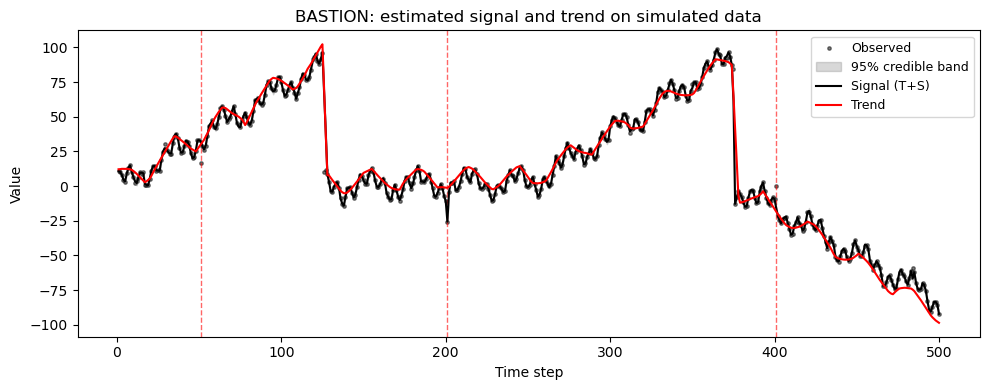

In [4]:
trend_mean  = np.asarray(summary['Trend_sum']['Mean']).ravel()
trend_lo    = np.asarray(summary['Trend_sum']['CR_lower']).ravel()
trend_hi    = np.asarray(summary['Trend_sum']['CR_upper']).ravel()
signal_mean = np.asarray(summary['Signal_sum']['Mean']).ravel()
signal_lo   = np.asarray(summary['Signal_sum']['CR_lower']).ravel()
signal_hi   = np.asarray(summary['Signal_sum']['CR_upper']).ravel()
s7_mean     = np.asarray(summary['Seasonal7_sum']['Mean']).ravel()
s30_mean    = np.asarray(summary['Seasonal30_sum']['Mean']).ravel()

n = len(sim['y']); t = np.arange(1, n + 1)

fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(t, sim['y'], s=6, color='black', alpha=0.5, zorder=1, label='Observed')
ax.fill_between(t, signal_lo, signal_hi, color='grey', alpha=0.3, zorder=2,
                label='95% credible band')
ax.plot(t, signal_mean, linewidth=1.5, color='black', zorder=3, label='Signal (T+S)')
ax.plot(t, trend_mean,  linewidth=1.5, color='red',   zorder=4, label='Trend')
for i in sim['outliers']:
    ax.axvline(i + 1, color='red', linestyle='--', linewidth=1.0, alpha=0.6)
ax.set_xlabel('Time step'); ax.set_ylabel('Value')
ax.set_title('BASTION: estimated signal and trend on simulated data')
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'sim_signal.pdf'), dpi=150, bbox_inches='tight')
plt.show()

## 4. Recovered Trend vs Truth

The grey band is the 95% posterior credible interval for the trend alone.  BASTION's global-local shrinkage prior adapts sharply at the four breakpoints while remaining smooth elsewhere.

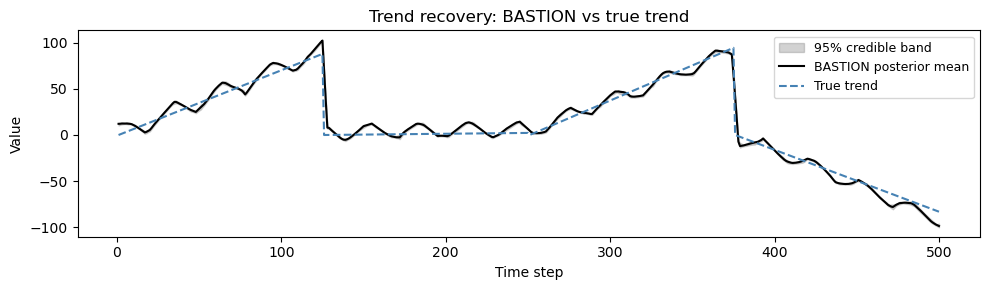

This run -- Trend MSE : 59.841
This run -- Signal MSE: 10.927


In [5]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.fill_between(t, trend_lo, trend_hi, color='grey', alpha=0.35,
                label='95% credible band')
ax.plot(t, trend_mean, linewidth=1.5, color='black', label='BASTION posterior mean')
ax.plot(t, sim['T'],   linewidth=1.5, color='steelblue', linestyle='--',
        label='True trend')
ax.set_xlabel('Time step'); ax.set_ylabel('Value')
ax.set_title('Trend recovery: BASTION vs true trend')
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'sim_trend.pdf'), dpi=150, bbox_inches='tight')
plt.show()

mse_trend  = float(np.mean((trend_mean  - sim['T']) ** 2))
mse_signal = float(np.mean((signal_mean - (sim['T'] + sim['S7'] + sim['S30'])) ** 2))
print(f'This run -- Trend MSE : {mse_trend:.3f}')
print(f'This run -- Signal MSE: {mse_signal:.3f}')

## 5. Seasonal Components

The two seasonal components (periods 7 and 30) with 95% credible bands compared against the true seasonal signals.

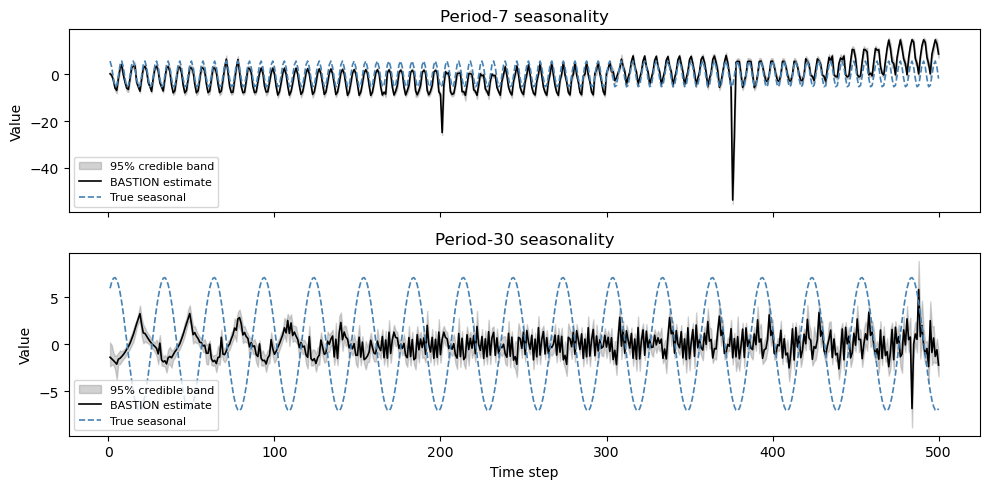

In [6]:
s7_lo  = np.asarray(summary['Seasonal7_sum']['CR_lower']).ravel()
s7_hi  = np.asarray(summary['Seasonal7_sum']['CR_upper']).ravel()
s30_lo = np.asarray(summary['Seasonal30_sum']['CR_lower']).ravel()
s30_hi = np.asarray(summary['Seasonal30_sum']['CR_upper']).ravel()

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
for ax, mean, lo, hi, true_, label in [
    (axes[0], s7_mean,  s7_lo,  s7_hi,  sim['S7'],  'Period-7 seasonality'),
    (axes[1], s30_mean, s30_lo, s30_hi, sim['S30'], 'Period-30 seasonality'),
]:
    ax.fill_between(t, lo, hi, color='grey', alpha=0.35, label='95% credible band')
    ax.plot(t, mean,  linewidth=1.2, color='black',     label='BASTION estimate')
    ax.plot(t, true_, linewidth=1.2, color='steelblue', linestyle='--',
            label='True seasonal')
    ax.set_ylabel('Value'); ax.set_title(label); ax.legend(fontsize=8)
axes[-1].set_xlabel('Time step')
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'sim_seasonality.pdf'), dpi=150,
            bbox_inches='tight')
plt.show()

## 6. Accuracy: MSE Table (Cho & Matteson 2026, Table 2)

The table below compares MSE for **DGP 1** (piecewise-linear trend, two Fourier seasonalities, constant noise, point outliers). TBATS, MSTL, and STR are not part of `pybastion` — their values are copied from the paper for reference. The **'This run'** column is computed from the current notebook execution.

In [7]:
# Seasonality MSE: compare combined posterior mean S7+S30 against true S7+S30
mse_season = float(np.mean(((s7_mean + s30_mean) - (sim['S7'] + sim['S30'])) ** 2))

table2 = pd.DataFrame(
    {
        'Signal MSE':   [13.878, 11.760, 10.829, 0.376, round(mse_signal, 3)],
        'Trend MSE':    [ 3.624, 13.227, 13.785, 0.581, round(mse_trend,  3)],
        'Seasonal MSE': [11.672,  2.712,  2.575, 0.536, round(mse_season, 3)],
    },
    index=['TBATS', 'MSTL', 'STR', 'BASTION (paper)', 'BASTION (this run)'],
)
print('Table 2 (DGP 1) -- MSE, lower is better')
print(table2.to_string())
print()
print('Paper values: 1 000-replicate averages (Cho & Matteson 2026, Table 2).')
print('"This run": single-replicate estimate computed in this notebook.')

Table 2 (DGP 1) -- MSE, lower is better
                    Signal MSE  Trend MSE  Seasonal MSE
TBATS                   13.878      3.624        11.672
MSTL                    11.760     13.227         2.712
STR                     10.829     13.785         2.575
BASTION (paper)          0.376      0.581         0.536
BASTION (this run)      10.927     59.841        46.821

Paper values: 1 000-replicate averages (Cho & Matteson 2026, Table 2).
"This run": single-replicate estimate computed in this notebook.


## 7. Uncertainty: Coverage Table (Cho & Matteson 2026, Table 3)

A key advantage of BASTION is calibrated uncertainty.  The **'This run'** column shows the time-average pointwise coverage: the fraction of time steps where the true value falls inside the 95% posterior credible interval. This is a single-replicate analogue of the simulation-average coverage in the paper.

In [8]:
true_signal = sim['T'] + sim['S7'] + sim['S30']
cov_signal  = float(np.mean((signal_lo <= true_signal) & (true_signal <= signal_hi)))
cov_trend   = float(np.mean((trend_lo  <= sim['T'])    & (sim['T']    <= trend_hi)))
cov_s7      = float(np.mean((s7_lo     <= sim['S7'])   & (sim['S7']   <= s7_hi)))
cov_s30     = float(np.mean((s30_lo    <= sim['S30'])  & (sim['S30']  <= s30_hi)))

table3 = pd.DataFrame(
    {
        'STR (paper)':        [0.799, 0.616, 0.815,  '—'],
        'BASTION (paper)':    [0.998, 0.970, 0.999,  '—'],
        'BASTION (this run)': [
            round(cov_signal, 3),
            round(cov_trend,  3),
            round(cov_s7,     3),
            round(cov_s30,    3),
        ],
    },
    index=['Signal', 'Trend', 'Seasonal (period 7)', 'Seasonal (period 30)'],
)
print('Table 3 (DGP 1) -- 95% coverage, higher is better')
print(table3.to_string())
print()
print('Paper values: simulation-average over 1 000 reps (Cho & Matteson 2026, Table 3).')
print('"This run": time-average pointwise coverage from a single replicate.')
print('Note: the paper reports a combined Seasonality row; periods are shown separately.')

Table 3 (DGP 1) -- 95% coverage, higher is better
                     STR (paper) BASTION (paper)  BASTION (this run)
Signal                     0.799           0.998               0.504
Trend                      0.616            0.97               0.084
Seasonal (period 7)        0.815           0.999               0.124
Seasonal (period 30)           —               —               0.062

Paper values: simulation-average over 1 000 reps (Cho & Matteson 2026, Table 3).
"This run": time-average pointwise coverage from a single replicate.
Note: the paper reports a combined Seasonality row; periods are shown separately.
